In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from helper_functions.helper_functions import *
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernelSmarterRefine,BnetMean
from torch.utils.data import DataLoader
from tqdm import tqdm
from pulse_method.toolbox_pulse import *

In [2]:
sim=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001.npz",allow_pickle=True)
experiment=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/Experimental_sample/exp_rb/2026_03_18_CFRP_FBH_5s_30s_top_symetrical.npz',allow_pickle=True)

Text(0.5, 1.0, 'Experimental data')

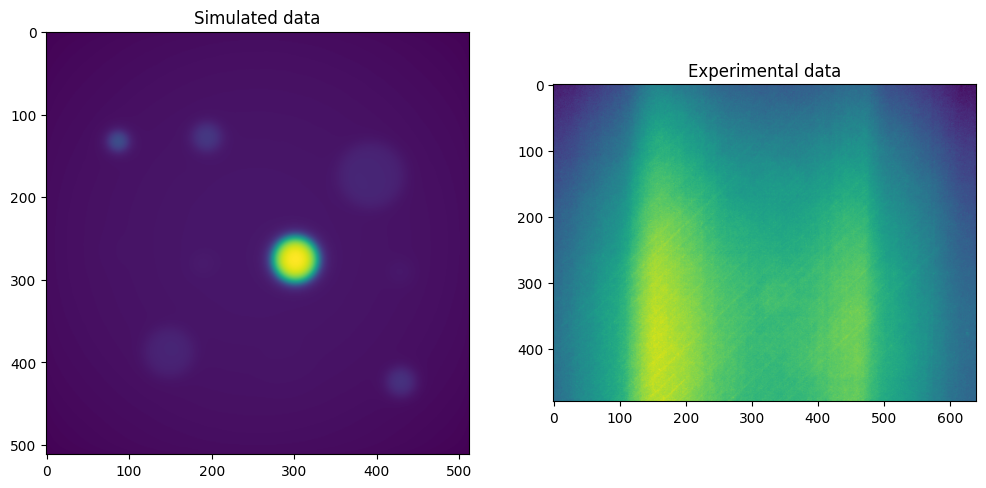

In [31]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(sim['data'][100,:,:])
plt.title('Simulated data')

plt.subplot(1,2,2)
plt.imshow(experiment['data'][100,:,:])
plt.title('Experimental data')

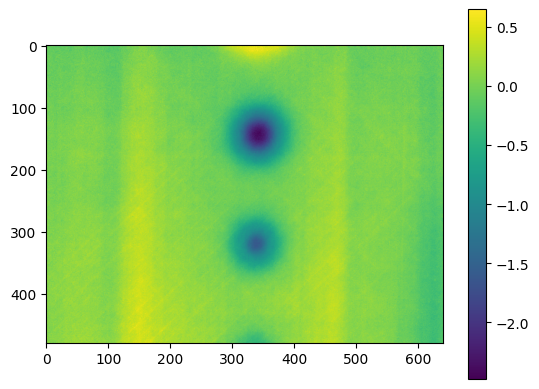

In [26]:
A_r=A_r.reshape(T,H,-1)
plt.imshow(A_r[250])
plt.colorbar()

Text(0, 0.5, 'Delta Temperature (°C)')

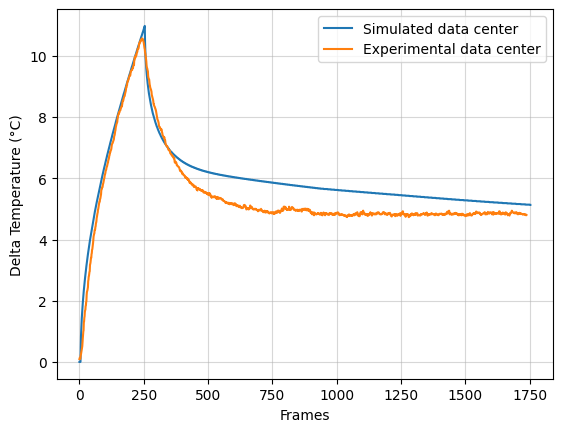

In [4]:

plt.plot(sim['data'][:,256,256]-20,label='Simulated data center')
plt.plot(experiment['data'][:,240,320],label='Experimental data center')
plt.grid(alpha=0.5)
plt.legend()
plt.xlabel('Frames')
plt.ylabel('Delta Temperature (°C)')

In [28]:
operator=thermograms(height=480,width=640)

In [7]:
phase,mag=operator.PPT(experiment['data'])


In [29]:
Eofs,_=operator.PCT(experiment['data'],n_components=10)

Text(0.5, 1.0, 'EOF of PCT')

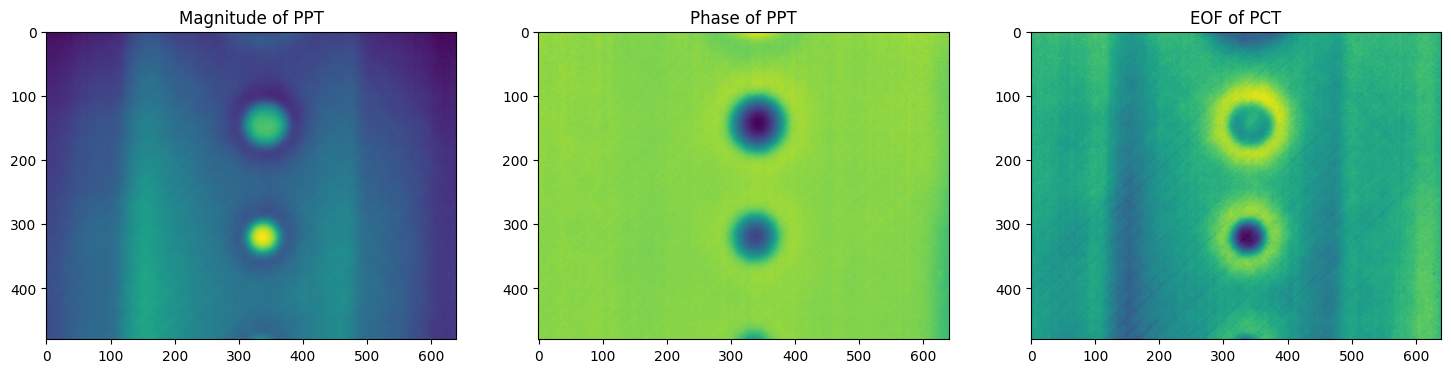

In [9]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(mag[1,:,:])
plt.title('Magnitude of PPT')

plt.subplot(1,3,2)
plt.imshow(phase[1,:,:])
plt.title('Phase of PPT')

plt.subplot(1,3,3)
plt.imshow(Eofs[2,:,:])
plt.title('EOF of PCT')


Text(0.5, 1.0, 'EOF of PCT')

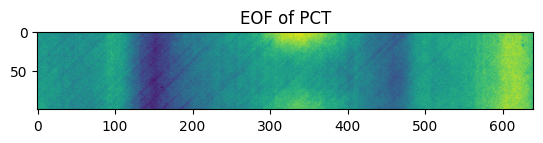

In [12]:
plt.imshow(Eofs[2,360:460,:])
plt.title('EOF of PCT')

In [33]:
device = 'cuda'
pin_memory = True
step = 480
THICKNESS_MM = 3.5  # sample thickness

model_path = '/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs_official/smart_net_H_C_domain/model_epoch_18.pth'

# Mode of the experimentation
data = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/Experimental_sample/exp_bscans'
depth = '/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/Experimental_sample/exp_masks'

sigma_list = [0.065] 
noise_augmentation=ComposeBScanTransforms([NoiseAdditionExperiment(sigma=sigma_list[-1])])

model=BnetSmallKernelSmarterRefine().to(device)
# model=BnetMean().to(device)
state_dict=torch.load(model_path)
model.load_state_dict(state_dict)
model.eval()

# validation (robustness metric only)
test_dataset = BScanDepthDataset(
    bscan_dir=data,
    depth_dir=depth,
    transform=None,
    normalization_path="/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/normalization_params.npz",
    derivative_mode=None,
    log_scaling=True,
    cooling_phase=False
)

# -------------------------
# Loaders
# -------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=pin_memory
)

In [34]:
model.eval()
pred_all = []


with torch.no_grad():
    for X, mask in tqdm(test_loader):

        X = X.to(device)
        pred = model(X)
        pred_all.append(pred.cpu())
        

pred_all = torch.cat(pred_all, dim=0)


100%|██████████| 30/30 [00:04<00:00,  6.16it/s]


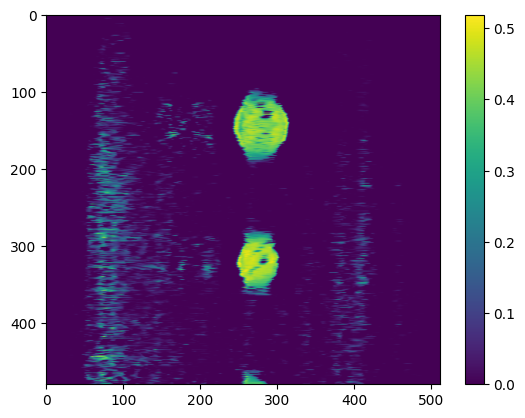

In [35]:
plt.imshow(pred_all)
plt.colorbar()

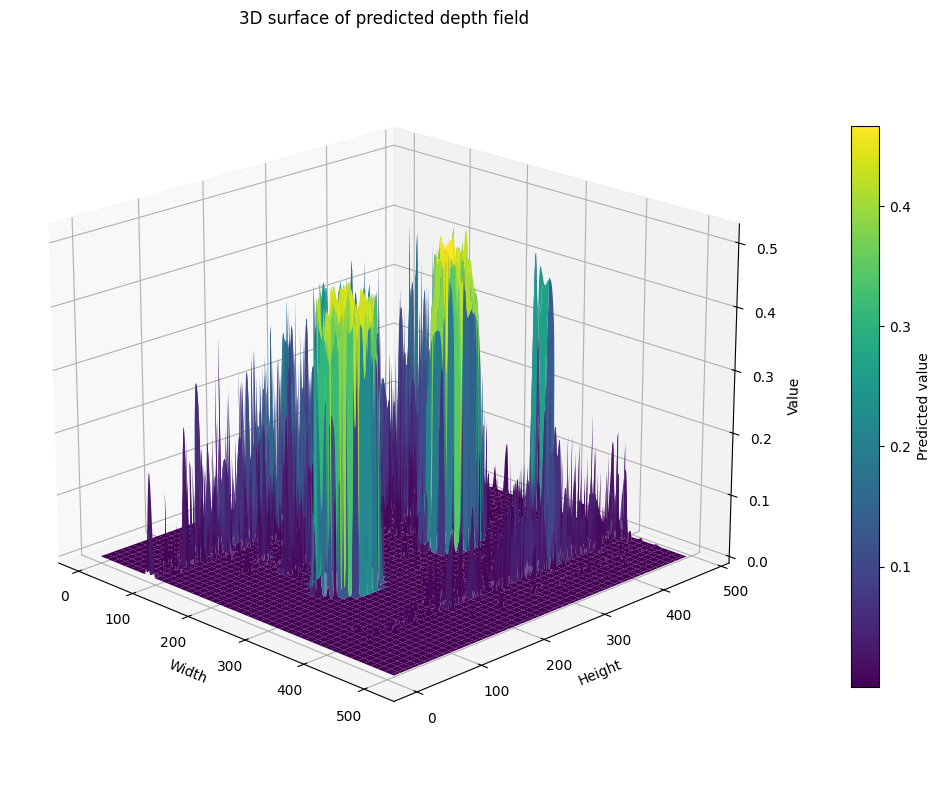

In [41]:
tomografic_reconstruction(pred_all,elev=20,azim=-45)

Text(0.5, 1.0, 'Domain calibration')

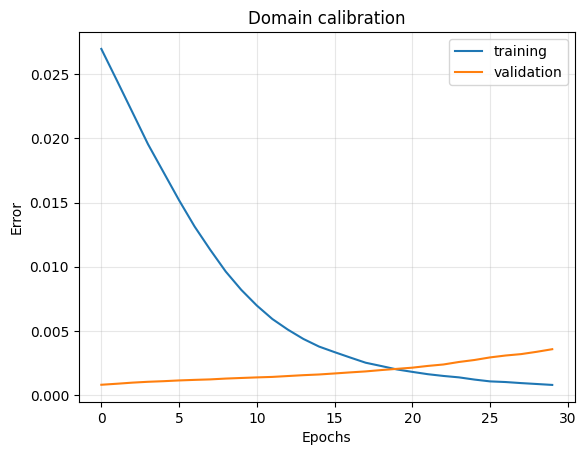

In [4]:
train_path = '/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs_official/smart_net_H_C_domain/train_log.pt'
val_path = '/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs_official/smart_net_H_C_domain/val_clean_log.pt'

train=torch.load(train_path)
val=torch.load(val_path)

plt.plot(train,label='training')
plt.plot(val,label='validation')
plt.grid(alpha=0.3)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.title('Domain calibration')